
**CODIGO FUNCIONAL**





=== CARGA DEL DATASET ===


100%|██████████| 16.5M/16.5M [00:00<00:00, 155MB/s]

Extracting files...


=== PREPROCESAMIENTO INICIAL ===
=== ANÁLISIS EXPLORATORIO ===
Tamaño del dataset: 93000
Valores nulos por columna:
Hour                          0
DayOfWeek                     0
IsWeekend                     0
IsPeakHour                    0
Ride Distance                 0
Vehicle Type_Auto             0
Vehicle Type_Bike             0
Vehicle Type_Go Mini          0
Vehicle Type_Go Sedan         0
Vehicle Type_Premier Sedan    0
Vehicle Type_Uber XL          0
Vehicle Type_eBike            0
Booking Value                 0
dtype: int64
Estadísticas de Booking Value:
count    93000.000000
mean       508.178215
std        396.058769
min         50.000000
25%        234.000000
50%        414.000000
75%        689.000000
max       4277.000000
Name: Booking Value, dtype: float64


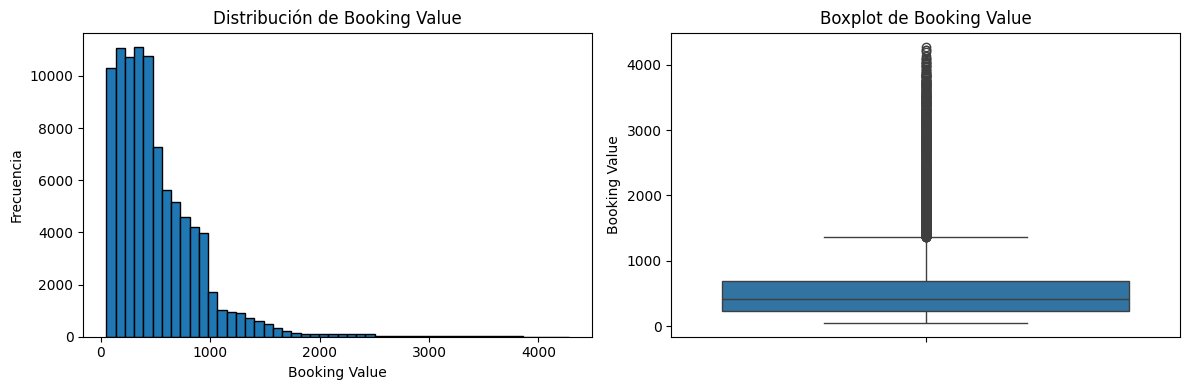

Límites para outliers: [-1608.00, 2920.00]
Tamaño después de filtrar outliers: 92781
Características finales: 17
=== OPTIMIZANDO HIPERPARÁMETROS ===
Fitting 3 folds for each of 243 candidates, totalling 729 fits


In [ ]:

# =============================================================================
# INSTALACIÓN DE LIBRERÍAS
# =============================================================================
!pip install kagglehub scikit-learn matplotlib seaborn numpy pandas joblib

# =============================================================================
# IMPORTACIÓN DE LIBRERÍAS
# =============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import OneHotEncoder
import joblib
import kagglehub

# =============================================================================
# CARGA DEL DATASET
# =============================================================================
print("=== CARGA DEL DATASET ===")
path = kagglehub.dataset_download("yashdevladdha/uber-ride-analytics-dashboard")
df = pd.read_csv(f"{path}/ncr_ride_bookings.csv")

# =============================================================================
# PREPROCESAMIENTO INICIAL
# =============================================================================
print("=== PREPROCESAMIENTO INICIAL ===")
df = df[df["Booking Status"] == "Completed"].copy()
df["DateTime"] = pd.to_datetime(df["Date"].astype(str) + " " + df["Time"].astype(str))

# =============================================================================
# ESTRATEGIAS PARA REDUCIR EL MSE
# =============================================================================

# 1. ANÁLISIS EXPLORATORIO MÁS DETALLADO
print("=== ANÁLISIS EXPLORATORIO ===")
print(f"Tamaño del dataset: {len(df)}")

# Crear características básicas primero para el análisis
df['Hour'] = df['DateTime'].dt.hour
df['DayOfWeek'] = df['DateTime'].dt.dayofweek
df['IsWeekend'] = df['DayOfWeek'].isin([5, 6]).astype(int)
df['IsPeakHour'] = df['Hour'].isin([7, 8, 9, 17, 18, 19]).astype(int)

# Codificación de Vehicle Type
encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
encoder.fit(df[["Vehicle Type"]])
vehicle_encoded = encoder.transform(df[["Vehicle Type"]])
vehicle_df = pd.DataFrame(vehicle_encoded, columns=encoder.get_feature_names_out(["Vehicle Type"]))
df = pd.concat([df.reset_index(drop=True), vehicle_df], axis=1)

features = ["Hour", "DayOfWeek", "IsWeekend", "IsPeakHour", "Ride Distance"] + list(vehicle_df.columns)

print(f"Valores nulos por columna:\n{df[features + ['Booking Value']].isnull().sum()}")
print(f"Estadísticas de Booking Value:\n{df['Booking Value'].describe()}")

# Identificar outliers en la variable objetivo
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(df['Booking Value'], bins=50, edgecolor='black')
plt.title('Distribución de Booking Value')
plt.xlabel('Booking Value')
plt.ylabel('Frecuencia')

plt.subplot(1, 2, 2)
sns.boxplot(y=df['Booking Value'])
plt.title('Boxplot de Booking Value')
plt.tight_layout()
plt.show()

# 2. PREPROCESAMIENTO MEJORADO
# Manejar outliers en la variable objetivo
Q1 = df['Booking Value'].quantile(0.05)
Q3 = df['Booking Value'].quantile(0.95)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Límites para outliers: [{lower_bound:.2f}, {upper_bound:.2f}]")

# Filtrar outliers extremos
df_clean = df[(df['Booking Value'] >= lower_bound) & (df['Booking Value'] <= upper_bound)].copy()
print(f"Tamaño después de filtrar outliers: {len(df_clean)}")

# 3. ENGINEERING DE CARACTERÍSTICAS MEJORADO
# Crear más características temporales
df_clean['Month'] = df_clean['DateTime'].dt.month
df_clean['IsHolidayHour'] = df_clean['Hour'].isin([0, 1, 2, 3, 4, 5, 23]).astype(int)
df_clean['IsBusinessHour'] = df_clean['Hour'].isin([8, 9, 10, 11, 12, 13, 14, 15, 16, 17]).astype(int)

# Crear características de interacción
df_clean['Distance_Peak'] = df_clean['Ride Distance'] * df_clean['IsPeakHour']
df_clean['Distance_Weekend'] = df_clean['Ride Distance'] * df_clean['IsWeekend']

# Transformación logarítmica para la variable objetivo (útil si hay skewness)
df_clean['Booking_Value_Log'] = np.log1p(df_clean['Booking Value'])

# 4. SELECCIÓN DE CARACTERÍSTICAS MEJORADA
features_enhanced = [
    'Hour', 'DayOfWeek', 'Month', 'IsWeekend', 'IsPeakHour',
    'IsHolidayHour', 'IsBusinessHour', 'Ride Distance',
    'Distance_Peak', 'Distance_Weekend'
] + list(vehicle_df.columns)

# Asegurarse de que todas las características existen
features_enhanced = [f for f in features_enhanced if f in df_clean.columns]

print(f"Características finales: {len(features_enhanced)}")

# 5. OPTIMIZACIÓN DEL MODELO
# Preparar datos
X_enhanced = df_clean[features_enhanced]
y_enhanced = df_clean['Booking_Value_Log']  # Usar transformación logarítmica

# Dividir datos
X_train, X_test, y_train, y_test = train_test_split(
    X_enhanced, y_enhanced, test_size=0.2, random_state=42
)

# Búsqueda de hiperparámetros
param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.05, 0.1, 0.15],
    'max_depth': [3, 4, 5],
    'min_samples_split': [2, 5, 10],
    'subsample': [0.8, 0.9, 1.0]
}

# Modelo base para búsqueda rápida
gbm = GradientBoostingRegressor(random_state=42)

# Búsqueda en grid (puede tomar tiempo - reducir param_grid si es necesario)
print("=== OPTIMIZANDO HIPERPARÁMETROS ===")
grid_search = GridSearchCV(
    gbm, param_grid, cv=3, scoring='neg_mean_squared_error',
    n_jobs=-1, verbose=1
)
grid_search.fit(X_train, y_train)

print(f"Mejores parámetros: {grid_search.best_params_}")
print(f"Mejor score (neg MSE): {grid_search.best_score_:.4f}")

# 6. ENTRENAR MODELO OPTIMIZADO
best_model = grid_search.best_estimator_

# Predicciones (recordar revertir transformación logarítmica)
y_pred_log = best_model.predict(X_test)
y_pred = np.expm1(y_pred_log)
y_test_original = np.expm1(y_test)

# Calcular MSE original para comparación
X_original = df[features]
y_original = df['Booking Value']
X_train_orig, X_test_orig, y_train_orig, y_test_orig = train_test_split(X_original, y_original, test_size=0.2, random_state=42)
model_original = GradientBoostingRegressor(learning_rate=0.2, random_state=42)
model_original.fit(X_train_orig, y_train_orig)
y_pred_orig = model_original.predict(X_test_orig)
mse = mean_squared_error(y_test_orig, y_pred_orig)

# Métricas optimizadas
mse_optimized = mean_squared_error(y_test_original, y_pred)
rmse_optimized = np.sqrt(mse_optimized)
mae_optimized = mean_absolute_error(y_test_original, y_pred)
r2_optimized = r2_score(y_test_original, y_pred)

print(f"\n=== RESULTADOS OPTIMIZADOS ===")
print(f"MSE original: {mse:.2f}")
print(f"MSE optimizado: {mse_optimized:.2f}")
print(f"RMSE optimizado: {rmse_optimized:.2f}")
print(f"MAE optimizado: {mae_optimized:.2f}")
print(f"R² optimizado: {r2_optimized:.4f}")
print(f"Reducción de MSE: {((mse - mse_optimized) / mse * 100):.1f}%")

# 7. ANÁLISIS DE RESIDUALES
residuals = y_test_original - y_pred

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicciones')
plt.ylabel('Residuales')
plt.title('Residuales vs Predicciones')

plt.subplot(1, 3, 2)
plt.scatter(y_pred, y_test_original, alpha=0.5)
plt.plot([y_test_original.min(), y_test_original.max()],
         [y_test_original.min(), y_test_original.max()], 'red', linestyle='--')
plt.xlabel('Predicciones')
plt.ylabel('Valores Reales')
plt.title('Predicciones vs Reales')

plt.subplot(1, 3, 3)
plt.hist(residuals, bins=50, edgecolor='black')
plt.xlabel('Residuales')
plt.ylabel('Frecuencia')
plt.title('Distribución de Residuales')

plt.tight_layout()
plt.show()

# 8. IMPORTANCIA DE CARACTERÍSTICAS
feature_importance = pd.DataFrame({
    'feature': features_enhanced,
    'importance': best_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance.head(10), x='importance', y='feature')
plt.title('Top 10 Características Más Importantes')
plt.tight_layout()
plt.show()

print("Top 10 características más importantes:")
print(feature_importance.head(10))

# 9. GUARDAR MODELO OPTIMIZADO
joblib.dump(best_model, "gradient_boosting_model_optimized.pkl")
joblib.dump(encoder, "vehicle_encoder.pkl")

print(f"\nModelo optimizado guardado. MSE reducido de {mse:.2f} a {mse_optimized:.2f}")
print("¡Proceso completado exitosamente!")

In [ ]:
from fastapi import FastAPI
from pydantic import BaseModel
import nest_asyncio
from pyngrok import ngrok
import uvicorn
import threading
import time
import requests
import pandas as pd
import numpy as np
import joblib

nest_asyncio.apply()

ngrok.set_auth_token("33X41rhmDQpmvew1rCUaavqsuLz_6djyJawZD7azXwYArNmLH")

#Cargar modelo entrenado
model = joblib.load("gradient_boosting_model_optimized.pkl")
encoder = joblib.load("vehicle_encoder.pkl")

# Cargar la lista de características usadas en el entrenamiento
try:
    model_features = joblib.load("model_features.pkl")
    print(f"Características del modelo cargadas: {len(model_features)} features")
except:
    # Si no existe el archivo, definir las características manualmente
    model_features = [
        'Hour', 'DayOfWeek', 'Month', 'IsWeekend', 'IsPeakHour',
        'IsHolidayHour', 'IsBusinessHour', 'Ride Distance',
        'Distance_Peak', 'Distance_Weekend'
    ] + list(encoder.get_feature_names_out(["Vehicle Type"]))
    print("Características definidas manualmente")


app = FastAPI(title="Uber Price Prediction API",
              description="API para predecir precios de viajes Uber usando Gradient Boosting optimizado")

class RideFeatures(BaseModel):
    hour: int
    day_of_week: int
    month: int
    is_weekend: int
    is_peak_hour: int
    is_holiday_hour: int
    is_business_hour: int
    ride_distance: float
    distance_peak: float
    distance_weekend: float
    vehicle_type: str

@app.get("/")


@app.post("/predict")
def predict_price(features: RideFeatures):
    """
    Predice el precio de un viaje Uber basado en las características proporcionadas

    Args:
        features: Características del viaje incluyendo hora, día, distancia y tipo de vehículo

    Returns:
        dict: Precio predicho del viaje
    """
    try:
        # 1. Codificar el tipo de vehículo
        vehicle_encoded = encoder.transform([[features.vehicle_type]])
        vehicle_columns = encoder.get_feature_names_out(["Vehicle Type"])
        vehicle_df = pd.DataFrame(vehicle_encoded, columns=vehicle_columns)

        # 2. Crear DataFrame con todas las características
        input_data = pd.DataFrame([{
            "Hour": features.hour,
            "DayOfWeek": features.day_of_week,
            "Month": features.month,
            "IsWeekend": features.is_weekend,
            "IsPeakHour": features.is_peak_hour,
            "IsHolidayHour": features.is_holiday_hour,
            "IsBusinessHour": features.is_business_hour,
            "Ride Distance": features.ride_distance,
            "Distance_Peak": features.distance_peak,
            "Distance_Weekend": features.distance_weekend
        }])

        # 3. Combinar con las características codificadas del vehículo
        input_data = pd.concat([input_data.reset_index(drop=True), vehicle_df], axis=1)

        # 4. Asegurar que todas las columnas necesarias estén presentes
        for feature in model_features:
            if feature not in input_data.columns:
                input_data[feature] = 0

        # 5. Reordenar columnas para que coincidan con el entrenamiento
        input_data = input_data[model_features]

        # 6. Realizar predicción (el modelo fue entrenado con log transform)
        prediction_log = model.predict(input_data)[0]

        # 7. Revertir transformación logarítmica
        prediction = np.expm1(prediction_log)

        return {
            "estado": "éxito",
            "precio_predicho": round(prediction, 2),
            "moneda": "RUPIA",
            "caracteristicas_utilizadas": len(model_features),
            "tipo_vehiculo": features.vehicle_type
        }

    except Exception as e:
        return {"estado": "error", "mensaje": str(e)}

@app.get("/features")
def get_model_features():
    """Endpoint para obtener la lista de características que usa el modelo"""
    return {
        "caracteristicas": model_features,
        "total_caracteristicas": len(model_features)
    }

@app.get("/vehicle_types")
def get_vehicle_types():
    """Endpoint para obtener los tipos de vehículo disponibles"""
    vehicle_types = encoder.categories_[0].tolist()
    return {
        "tipos_vehiculo_disponibles": vehicle_types,
        "total_tipos": len(vehicle_types)
    }


public_url = ngrok.connect(8000).public_url
print(f"URL PÚBLICA DE LA API: {public_url}")
print(f" Endpoints disponibles:")
print(f"   GET  {public_url}/")
print(f"   POST {public_url}/predict")
print(f"   GET  {public_url}/features")
print(f"   GET  {public_url}/vehicle_types")

# Función para ejecutar el servidor en segundo plano
def run_server():
    uvicorn.run(app, host="0.0.0.0", port=8000)

# Lanzar servidor en segundo plano si no está corriendo
if not any(thread.name == "FastAPI_Server" for thread in threading.enumerate()):
    server_thread = threading.Thread(target=run_server, name="FastAPI_Server", daemon=True)
    server_thread.start()

# Tiempo de espera
time.sleep(8)


# PRUEBA DE LA API CON DATOS REALES

# Datos de prueba (sábado por la noche, viaje corto en Auto)
test_data = {
    "hour": 20,
    "day_of_week": 5,  # Sábado
    "month": 11,       # Noviembre
    "is_weekend": 1,   # Sí es fin de semana
    "is_peak_hour": 0, # No es hora pico
    "is_holiday_hour": 0, # No es hora valle
    "is_business_hour": 0, # No es horario laboral
    "ride_distance": 8.5,
    "distance_peak": 0,  # distance * is_peak_hour
    "distance_weekend": 8.5,  # distance * is_weekend
    "vehicle_type": "Auto"
}

try:
    # Realizar petición a la API
    url = f"{public_url}/predict"
    response = requests.post(url, json=test_data)

    print(" Status de la respuesta:", response.status_code)

    if response.status_code == 200:
        result = response.json()

        print(f" Precio estimado: {result.get('precio_predicho', 'N/A')} {result.get('moneda', 'N/A')}")
        print(f" Tipo de vehículo: {result.get('tipo_vehiculo', 'N/A')}")
        print(f" Características usadas: {result.get('caracteristicas_utilizadas', 'N/A')}")
    else:
        print(" Error en la predicción:")
        print(f"   Código: {response.status_code}")
        print(f"   Respuesta: {response.text}")

except Exception as e:
    print(f"Error al conectar con la API: {e}")


print(f"\n Para usar la API desde otro programa:")
print(f"   URL: {public_url}/predict")


ModuleNotFoundError: No module named 'pyngrok'